<a href="https://colab.research.google.com/github/jebinjoshwa-hub/aiml-jebin/blob/main/jebin_aiml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model Accuracy: 70.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.31      0.40        13
           1       0.73      0.89      0.80        27

    accuracy                           0.70        40
   macro avg       0.65      0.60      0.60        40
weighted avg       0.68      0.70      0.67        40



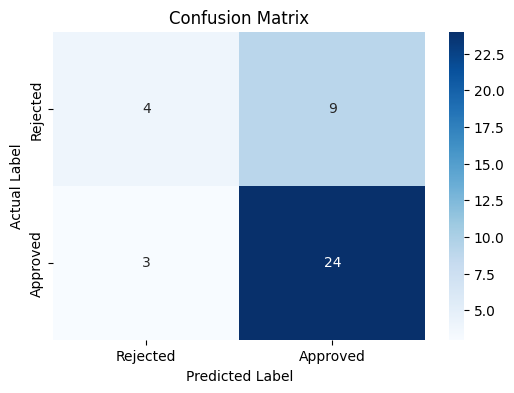

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare Features (X) and Target (y)
# Drop 'User_ID' as it's just an identifier, and 'Loan_Status' which is our target variable
X = df.drop(columns=['User_ID', 'Loan_Status'])
y = df['Loan_Status'].map({'Approved': 1, 'Rejected': 0})  # Encode target to binary (1 = Approved, 0 = Rejected)

# 2. Split the dataset into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Standardize/Scale the features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Initialize and Train the Logistic Regression Model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# 5. Make Predictions
y_pred = model.predict(X_test_scaled)

# 6. Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Generate dummy data for 200 users
n_users = 200

user_ids = [f"USER_{i:03d}" for i in range(1, n_users + 1)]
age = np.random.randint(21, 65, size=n_users)
annual_income = np.random.randint(30000, 150000, size=n_users)
credit_score = np.random.randint(300, 850, size=n_users)
loan_amount = np.random.randint(5000, 80000, size=n_users)
loan_term_months = np.random.choice([12, 24, 36, 48, 60], size=n_users)

# Calculate Debt-to-Income (DTI) ratio as a percentage (with some randomness)
debt_to_income_ratio = np.round((loan_amount / loan_term_months) / (annual_income / 12) * 100, 2)

# Determine loan status based on Credit Score and DTI ratio
# High credit score and low DTI ratio increase the probability of approval
approval_prob = (credit_score / 850.0) * 0.6 + (1 - (debt_to_income_ratio / 100.0)) * 0.4
approval_prob = np.clip(approval_prob, 0.05, 0.95)  # Keep probability bounds realistic

loan_status = [np.random.choice(["Approved", "Rejected"], p=[prob, 1 - prob]) for prob in approval_prob]

# Create DataFrame with 8 columns
df = pd.DataFrame({
    "User_ID": user_ids,
    "Age": age,
    "Annual_Income_USD": annual_income,
    "Credit_Score": credit_score,
    "Loan_Amount_USD": loan_amount,
    "Loan_Term_Months": loan_term_months,
    "Debt_to_Income_Ratio": debt_to_income_ratio,
    "Loan_Status": loan_status
})

# Save the generated dataset
df.to_csv("loan_approval_dataset.csv", index=False)

print(f"Successfully created 'loan_approval_dataset.csv' with {df.shape[0]} rows and {df.shape[1]} columns.")
display(df.head())
display(df.info())


Successfully created 'loan_approval_dataset.csv' with 200 rows and 8 columns.


,User_ID,Age,Annual_Income_USD,Credit_Score,Loan_Amount_USD,Loan_Term_Months,Debt_to_Income_Ratio,Loan_Status
0,USER_001,59,68623,587,8709,24,6.35,Rejected
1,USER_002,49,37392,454,35355,48,23.64,Approved
2,USER_003,35,85680,789,60771,24,35.46,Approved
3,USER_004,63,76717,685,62799,60,16.37,Approved
4,USER_005,28,149937,403,18116,24,6.04,Rejected


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   User_ID               200 non-null    object 
 1   Age                   200 non-null    int64  
 2   Annual_Income_USD     200 non-null    int64  
 3   Credit_Score          200 non-null    int64  
 4   Loan_Amount_USD       200 non-null    int64  
 5   Loan_Term_Months      200 non-null    int64  
 6   Debt_to_Income_Ratio  200 non-null    float64
 7   Loan_Status           200 non-null    object 
dtypes: float64(1), int64(5), object(2)
memory usage: 12.6+ KB


None

In [ ]:
#@title Loan Approval Predictor (Custom Tester) { run: "auto" }

import numpy as np
import pandas as pd

# --- Form Fields ---
Age = 60 #@param {type:"slider", min:18, max:100, step:1}
Annual_Income_USD = 150015 #@param {type:"number"}
Credit_Score = 300 #@param {type:"slider", min:300, max:850, step:1}
Loan_Amount_USD = 25000 #@param {type:"number"}
Loan_Term_Months = 36 #@param [12, 24, 36, 48, 60] {type:"raw"}

# --- Calculations & Prediction ---
# Calculate Debt-to-Income (DTI) ratio matching the logic in the training dataset
calculated_dti = np.round((Loan_Amount_USD / Loan_Term_Months) / (Annual_Income_USD / 12) * 100, 2)

# Prepare input data matching model feature ordering
# Order: ['Age', 'Annual_Income_USD', 'Credit_Score', 'Loan_Amount_USD', 'Loan_Term_Months', 'Debt_to_Income_Ratio']
input_data = pd.DataFrame([[Age, Annual_Income_USD, Credit_Score, Loan_Amount_USD, Loan_Term_Months, calculated_dti]],
                           columns=['Age', 'Annual_Income_USD', 'Credit_Score', 'Loan_Amount_USD', 'Loan_Term_Months', 'Debt_to_Income_Ratio'])

# Scale the features using the pre-fitted scaler
input_scaled = scaler.transform(input_data)

# Predict using our logistic regression model
prediction = model.predict(input_scaled)[0]
prediction_prob = model.predict_proba(input_scaled)[0]

# Output formatting
status_mapping = {1: "Approved ✅", 0: "Rejected ❌"}
predicted_status = status_mapping[prediction]
approval_chance = prediction_prob[1]

# Print Summary
print("=" * 40)
print("           LOAN EVALUATION SUMMARY         ")
print("=" * 40)
print(f" Calculated DTI Ratio : {calculated_dti}%")
print(f" Credit Score Status  : {Credit_Score} / 850")
print("-" * 40)
print(f" Prediction           : {predicted_status}")
print(f" Probability of Approval: {approval_chance:.2%}")
print("=" * 40)

           LOAN EVALUATION SUMMARY         
 Calculated DTI Ratio : 5.56%
 Credit Score Status  : 300 / 850
----------------------------------------
 Prediction           : Approved ✅
 Probability of Approval: 58.88%


Runtime memory was empty. Automatically training the model to resolve dependencies...
Training Accuracy (indicates potential Bias): 73.12%
Testing Accuracy (indicates potential Variance): 70.00%
Generalization Gap (Difference): 3.12%

Analysis: The model shows a balanced bias-variance tradeoff. It generalizes reasonably well from the training set to the test set.


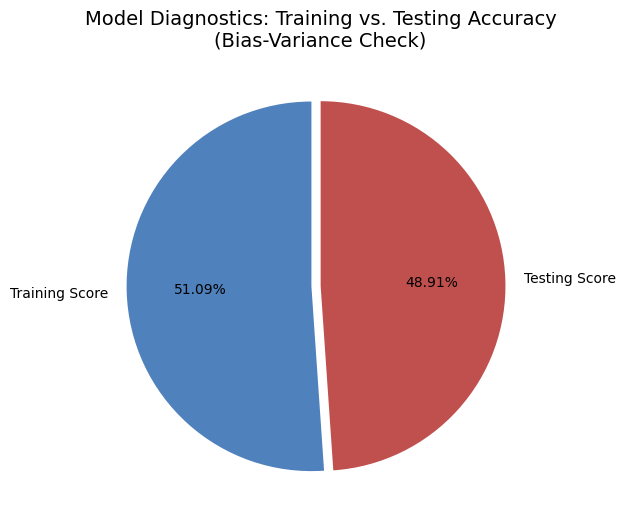

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Safely load data and train the model if not already present in the runtime memory
try:
    # Check if variables are already defined
    model
    X_train_scaled
    y_train
    X_test_scaled
    y_test
except NameError:
    print("Runtime memory was empty. Automatically training the model to resolve dependencies...")
    try:
        df = pd.read_csv("loan_approval_dataset.csv")
    except FileNotFoundError:
        # Regenerate data if the CSV file is also missing
        np.random.seed(42)
        n_users = 200
        user_ids = [f"USER_{i:03d}" for i in range(1, n_users + 1)]
        age = np.random.randint(21, 65, size=n_users)
        annual_income = np.random.randint(30000, 150000, size=n_users)
        credit_score = np.random.randint(300, 850, size=n_users)
        loan_amount = np.random.randint(5000, 80000, size=n_users)
        loan_term_months = np.random.choice([12, 24, 36, 48, 60], size=n_users)
        debt_to_income_ratio = np.round((loan_amount / loan_term_months) / (annual_income / 12) * 100, 2)
        approval_prob = (credit_score / 850.0) * 0.6 + (1 - (debt_to_income_ratio / 100.0)) * 0.4
        approval_prob = np.clip(approval_prob, 0.05, 0.95)
        loan_status = [np.random.choice(["Approved", "Rejected"], p=[prob, 1 - prob]) for prob in approval_prob]
        df = pd.DataFrame({
            "User_ID": user_ids,
            "Age": age,
            "Annual_Income_USD": annual_income,
            "Credit_Score": credit_score,
            "Loan_Amount_USD": loan_amount,
            "Loan_Term_Months": loan_term_months,
            "Debt_to_Income_Ratio": debt_to_income_ratio,
            "Loan_Status": loan_status
        })
        df.to_csv("loan_approval_dataset.csv", index=False)

    X = df.drop(columns=['User_ID', 'Loan_Status'])
    y = df['Loan_Status'].map({'Approved': 1, 'Rejected': 0})
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    model = LogisticRegression(random_state=42)
    model.fit(X_train_scaled, y_train)

# 1. Calculate training and testing metrics to analyze Bias and Variance
train_acc = model.score(X_train_scaled, y_train)
test_acc = model.score(X_test_scaled, y_test)

print(f"Training Accuracy (indicates potential Bias): {train_acc:.2%}")
print(f"Testing Accuracy (indicates potential Variance): {test_acc:.2%}")
print(f"Generalization Gap (Difference): {abs(train_acc - test_acc):.2%}\n")

# Diagnostics interpretation
if train_acc < 0.70:
    print("Analysis: The training accuracy is relatively low, suggesting a potential HIGH BIAS (underfitting). The model might be too simple to capture the underlying relationships.")
elif (train_acc - test_acc) > 0.12:
    print("Analysis: The training accuracy is significantly higher than the testing accuracy, suggesting HIGH VARIANCE (overfitting). The model is memorizing training patterns and failing to generalize well.")
else:
    print("Analysis: The model shows a balanced bias-variance tradeoff. It generalizes reasonably well from the training set to the test set.")

# 2. Plotting Bias-Variance / Training vs Testing Performance as a Pie Chart
categories = ['Training Score', 'Testing Score']
scores = [train_acc, test_acc]
colors = ['#4F81BD', '#C0504D']

plt.figure(figsize=(6, 6))
plt.pie(scores, labels=categories, autopct='%1.2f%%', startangle=90, colors=colors, explode=(0.05, 0))
plt.title('Model Diagnostics: Training vs. Testing Accuracy\n(Bias-Variance Check)', fontsize=14)
plt.show()

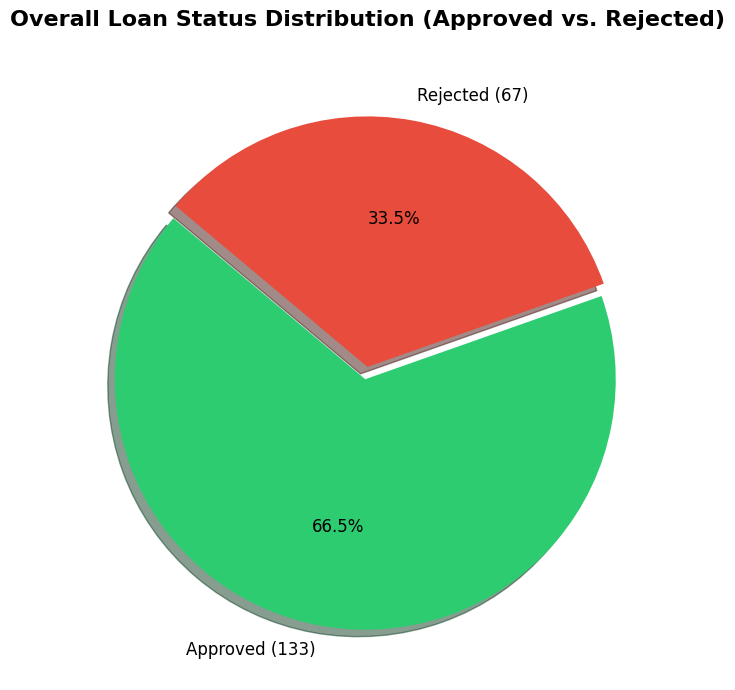

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the dataset
try:
    df_pie = pd.read_csv('loan_approval_dataset.csv')
except FileNotFoundError:
    # Fallback to the 'df' variable in memory if file is not found
    df_pie = df

# Count the occurrences of each status
status_counts = df_pie['Loan_Status'].value_counts()

# Colors and styling
colors = ['#2ecc71', '#e74c3c']  # Green for Approved, Red for Rejected
labels = [f"{label} ({count})" for label, count in zip(status_counts.index, status_counts.values)]

# Plotting the pie chart
plt.figure(figsize=(7, 7))
plt.pie(
    status_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=(0.05, 0),
    shadow=True,
    textprops={'fontsize': 12}
)

plt.title('Overall Loan Status Distribution (Approved vs. Rejected)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()